In [3]:
#testing
print("hello world") 

hello world


In [2]:
!pip install langchain langchain-community langchain-text-splitters docx2txt langchain-groq faiss-cpu sentence-transformers rank-bm25

In [4]:
# !pip install rank-bm25
!pip install rank_bm25 -q

In [5]:
from langchain_community.document_loaders import DirectoryLoader, Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import re

load_dotenv()

True

In [6]:
loader = DirectoryLoader(
    path="E:\\langgrapph_chat_ui\\rag-documents",
    glob="*.docx",
    loader_cls=Docx2txtLoader
)

documents = loader.load()
print(f"Loaded {len(documents)} document(s)")
print(documents[0].page_content[:500])

Loaded 1 document(s)
All product:
Product Name: Tactical cotton pant IX7  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200      Color: Khaki, Green, Gray

Product Name: Tactical cotton pant IX9  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200 Color: Khaki, Green, Gray, Black, Desert Khaki

Product name: Wrinkle Tactical Pant IX7 and IX9 series sizes: S, M, L, XL, XXL, XXXL price: Rs.2950 Color: Gray, Black, Olive Green

Product name: Half Pant IX7 series size: S, M, L, XL, XXL, XXXL Price: 2450 color: Navi Bl


In [7]:
def clean_text(text):
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = "\n".join(line.strip() for line in text.splitlines())
    return text.strip()

for doc in documents:
    doc.page_content = clean_text(doc.page_content)

print(documents[0].page_content[:500])

All product:
Product Name: Tactical cotton pant IX7  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200      Color: Khaki, Green, Gray

Product Name: Tactical cotton pant IX9  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200 Color: Khaki, Green, Gray, Black, Desert Khaki

Product name: Wrinkle Tactical Pant IX7 and IX9 series sizes: S, M, L, XL, XXL, XXXL price: Rs.2950 Color: Gray, Black, Olive Green

Product name: Half Pant IX7 series size: S, M, L, XL, XXL, XXXL Price: 2450 color: Navi Bl


In [8]:
total_chars = sum(len(doc.page_content) for doc in documents)
total_words = sum(len(doc.page_content.split()) for doc in documents)

print(f"Total documents  : {len(documents)}")
print(f"Total characters : {total_chars}")
print(f"Total words      : {total_words}")

for i, doc in enumerate(documents):
    print(f"\nDoc {i+1} preview  : {doc.page_content[:300]}")
    print("-" * 50)

if total_chars < 5_000:
    chunk_size    = 500
    chunk_overlap = 50
elif total_chars < 20_000:
    chunk_size    = 800
    chunk_overlap = 150
elif total_chars < 50_000:
    chunk_size    = 1000
    chunk_overlap = 200
elif total_chars < 100_000:
    chunk_size    = 1200
    chunk_overlap = 250
else:
    chunk_size    = 1500
    chunk_overlap = 300

print(f"\nTotal docs       : {len(documents)} docs")
print(f"Doc size         : {total_chars} chars")
print(f"Total words      : {total_words} words")
print(f"Using chunk_size : {chunk_size}")
print(f"Using overlap    : {chunk_overlap}")

Total documents  : 1
Total characters : 8190
Total words      : 1266

Doc 1 preview  : All product:
Product Name: Tactical cotton pant IX7  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200      Color: Khaki, Green, Gray

Product Name: Tactical cotton pant IX9  series  size: S, M, L, XL, XXL, XXXL Price: Rs.4200 Color: Khaki, Green, Gray, Black, Desert Khaki

Product name: Wrinkle T
--------------------------------------------------

Total docs       : 1 docs
Doc size         : 8190 chars
Total words      : 1266 words
Using chunk_size : 800
Using overlap    : 150


In [9]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

chunks = splitter.split_documents(documents)
print(f"Total chunks: {len(chunks)}")

Total chunks: 12


In [10]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vector_store = FAISS.from_documents(chunks, embeddings)
faiss_retriever = vector_store.as_retriever(search_kwargs={"k": 3})

print("Vector store ready")

C:\Users\Hp\AppData\Local\Temp\ipykernel_2812\2322023710.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1347.24it/s]


Vector store ready


In [11]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vector_store = FAISS.from_documents(chunks, embeddings)

# Dynamic k and fetch_k based on total chunks
total_chunks = len(chunks)

if total_chunks < 20:
    k, fetch_k = 4, 10
elif total_chunks < 50:
    k, fetch_k = 4, 20
elif total_chunks < 100:
    k, fetch_k = 5, 25
elif total_chunks < 200:
    k, fetch_k = 6, 30
else:
    k, fetch_k = 8, 40

retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={"k": k, "fetch_k": fetch_k}
)

print(f"Total chunks : {total_chunks}")
print(f"Using k      : {k}")
print(f"Using fetch_k: {fetch_k}")
print("Retriever ready")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2426.52it/s]


Total chunks : 12
Using k      : 4
Using fetch_k: 10
Retriever ready


In [ ]:
# similarity_retriever = vector_store.as_retriever(
#     search_type="similarity",
#     search_kwargs={"k": 4}
# )

In [12]:
@tool
def rag_tool(query: str) -> dict:
    """
    Retrieve relevant information from the product documents.
    Use this tool when the user asks about products, sizes, colors,
    prices or anything that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context  = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query":    query,
        "context":  context,
        "metadata": metadata
    }

In [83]:
llm = ChatGroq(
    # model="llama-3.1-8b-instant",
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [80]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

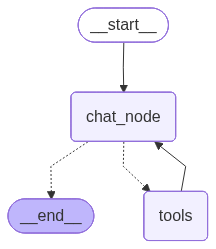

In [81]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile()
chatbot

In [84]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content="Do you have tactical items?"
            )
        ]
    }
)

print(result["messages"][-1].content)

We have tactical items such as:

1. Tactical cotton pant IX7 series - sizes: S, M, L, XL, XXL, XXXL, price: Rs.4200, colors: Khaki, Green, Gray
2. Tactical cotton pant IX9 series - sizes: S, M, L, XL, XXL, XXXL, price: Rs.4200, colors: Khaki, Green, Gray, Black, Desert Khaki
3. Wrinkle Tactical Pant IX7 and IX9 series - sizes: S, M, L, XL, XXL, XXXL, price: Rs.2950, colors: Gray, Black, Olive Green
4. Half Pant IX7 series - sizes: S, M, L, XL, XXL, XXXL, price: Rs.2450, colors: Navi Blue, Grey, Khaki, Mate Black
5. Half Pant IX9 series - sizes: S, M, L, XL, XXL, XXXL, price: Rs.2450, colors: Navi Blue, Grey, Khaki, Mate Black

You can purchase these items online or visit one of our physical stores. For more information, please refer to our website or contact one of our dealers.


In [ ]:
# prompt = PromptTemplate(
#     template="""
# You are a polite and helpful product assistant for a tactical gear store called MiniStore.
# Answer ONLY from the provided context below.
# If the context is insufficient, say "Sorry, this information is not available."

# When a product is available, ALWAYS mention:
# - Product name
# - Available sizes
# - Available colors
# - Price

# Keep your answer short, clear and friendly.

# Context:
# {context}

# Question: {question}

# Answer:
# """,
#     input_variables=["context", "question"]
# )

In [ ]:
# from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
# from langchain_core.output_parsers import StrOutputParser

# def format_docs(docs):
#     return "\n\n".join(doc.page_content for doc in docs)

# chain = (
#     RunnableParallel({
#         "context": retriever | RunnableLambda(format_docs),
#         "question": RunnablePassthrough()
#     })
#     | prompt
#     | llm
#     | StrOutputParser()
# )

# print("Chain ready")

Chain ready


In [ ]:
# response = chain.invoke("give me details about the tactical items")
# print(response)

We have the following tactical items available:

1. **IX7 Tactical Cotton Pant**
   - Available sizes: S, M, L, XL, XXL, XXXL
   - Available colors: Khaki, Green, Gray
   - Price: Rs.4200

2. **IX9 Tactical Cotton Pant**
   - Available sizes: S, M, L, XL, XXL, XXXL
   - Available colors: Khaki, Green, Gray, Black, Desert Khaki
   - Price: Rs.4200

3. **Wrinkle Tactical Pant (IX7 & IX9 series)**
   - Available sizes: S, M, L, XL, XXL, XXXL
   - Available colors: Gray, Black, Olive Green
   - Price: Rs.2950

4. **Half Pant (IX7 series)**
   - Available sizes: S, M, L, XL, XXL, XXXL
   - Available colors: Navi Blue, Grey, Khaki, Mate Black
   - Price: Rs.2450

5. **Half Pant (IX9 series)**
   - Available sizes: S, M, L, XL, XXL, XXXL
   - Available colors: Navi Blue, Grey, Khaki, Mate Black
   - Price: Rs.2450
